In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('Housing.csv')

print(df.head(10))

print("Shape:", df.shape)

print(df.dtypes)

print("Missing values:\n", df.isnull().sum())

      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      

In [2]:
# Remove duplicates
df = df.drop_duplicates()

df = df.dropna()

categorical_cols = ['mainroad', 'guestroom', 'basement',
                    'hotwaterheating', 'airconditioning',
                    'prefarea', 'furnishingstatus']

cols_to_encode = [col for col in categorical_cols if col in df.columns]

if cols_to_encode:
    df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

df = df.astype({col: int for col in df.select_dtypes(bool).columns})

print(df.head(3))
print("New shape:", df.shape)

      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2             1   
1  12250000  8960         4          4        4        3             1   
2  12250000  9960         3          2        2        2             1   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0              0             0                    0                    1   
1              0             0                    0                    1   
2              0             1                    0                    0   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0             1                                0                             0  
1             0                                0                             0  
2             1                                1                             0  
New shape: (545, 14)


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = df.drop('price', axis=1)
y = df['price']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print("=== Linear Regression ===")
print("MAE :", mean_absolute_error(y_test, lr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))
print("R²  :", r2_score(y_test, lr_preds))

#Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("\n=== Random Forest ===")
print("MAE :", mean_absolute_error(y_test, rf_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))
print("R²  :", r2_score(y_test, rf_preds))

=== Linear Regression ===
MAE : 970043.4039201637
RMSE: 1324506.9600914388
R²  : 0.6529242642153184

=== Random Forest ===
MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R²  : 0.611918531405699


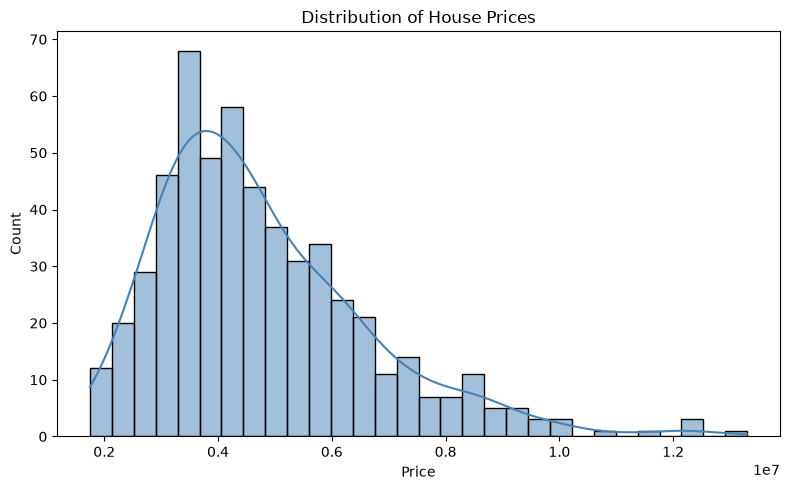

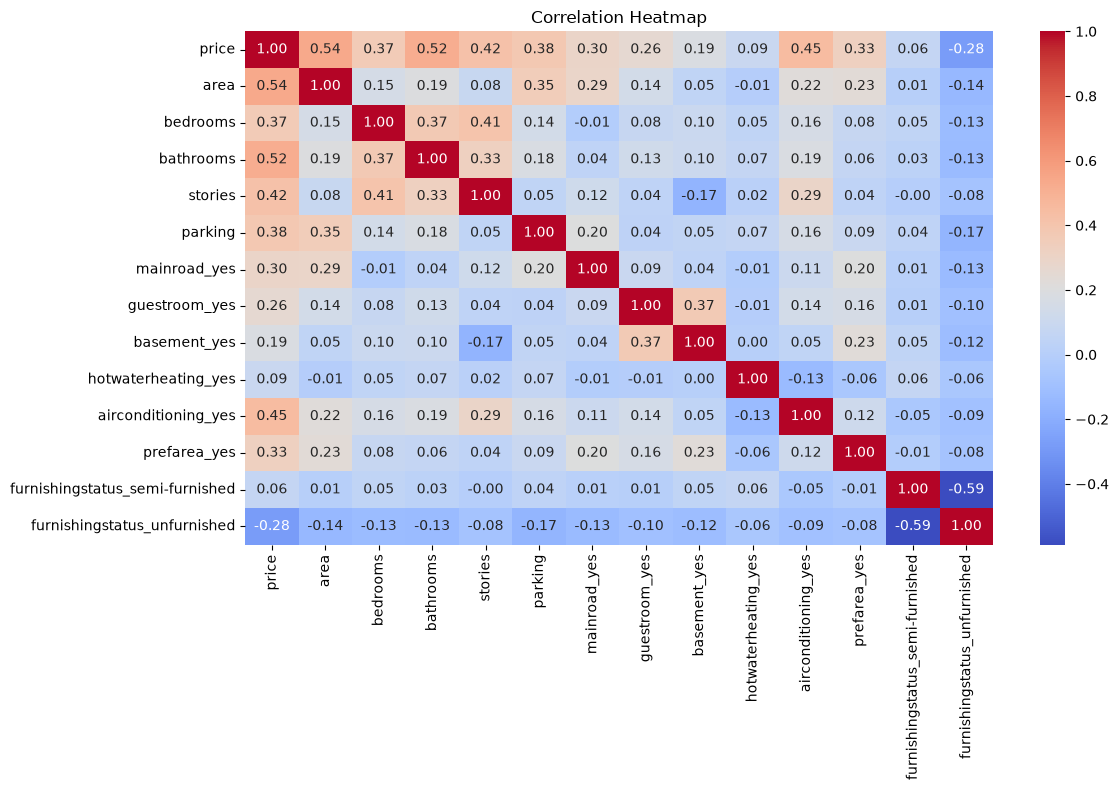

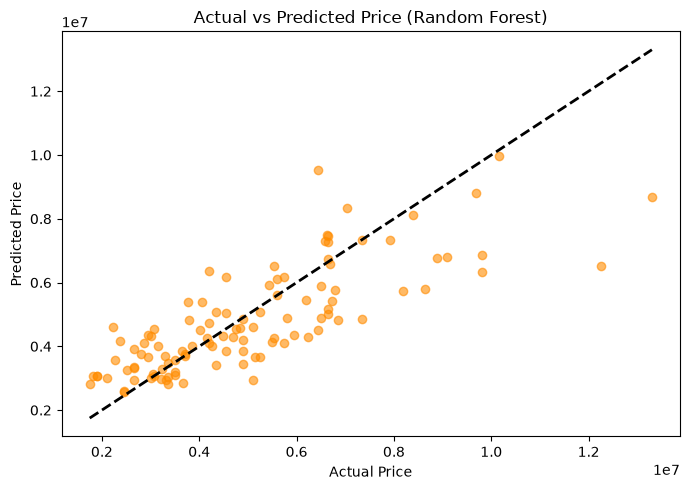

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create charts folder
os.makedirs('charts', exist_ok=True)

# Chart 1: Price Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png')
plt.show()

# Chart 2: Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png')
plt.show()

# Chart 3: Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test, rf_preds, alpha=0.6, color='darkorange')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price (Random Forest)')
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png')
plt.show()

Insights & Summary

When looking at the data, a few features clearly stood out as the 
biggest drivers of house price. The size of the house (area) had 
the strongest influence, followed closely by the number of bathrooms. 
Beyond that, having air conditioning and being located in a preferred 
area also made a noticeable difference to the price. Simply put, 
buyers are willing to pay significantly more for a spacious house 
with modern comforts in a good location.

The Linear Regression model performed reasonably well, explaining 
about 65% of the price variation with an average error of around 
₹9,70,000. For a real-world dataset with many unpredictable factors 
like neighborhood trends and buyer preferences, this is a decent 
result. The model won't give a perfect number, but it gets you 
into the right ballpark most of the time.

One thing that genuinely surprised me was that the simpler Linear 
Regression model actually outperformed the more advanced Random Forest 
model. I expected Random Forest to win, but it turns out that with 
a smaller dataset like this one (only 545 houses), the straightforward 
linear approach worked better because the price relationships in this 
data are fairly direct and predictable.

If I were advising a real estate business based on these findings, 
I would say — focus on area and bathrooms first when pricing a property. 
These two factors alone tell you a lot about what a house is worth. 
Investing in air conditioning and choosing properties in preferred 
localities can also command a premium, and should be factored into 
any pricing or investment decision.